In [1]:
%pip install shap
%pip install --upgrade scipy shap
%pip install "numpy<2" --force-reinstall

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
import shap

# Cargar dataset
df = pd.read_csv("features_ml_final.csv")

print(f"✓ Dataset cargado: {df.shape}")
print(f"\nColumnas disponibles:")
print(list(df.columns))

✓ Dataset cargado: (432, 45)

Columnas disponibles:
['date', 'line_id', 'avg_pressure', 'avg_temp', 'avg_h2s', 'avg_arab', 'avg_moisture', 'avg_vibration', 'avg_cr', 'CRTF_mean', 'CRTF_max', 'CCL_end', 't_est_end', 'RLY_mean', 'PTR_mean', 'HSI_mean', 'HSI_max', 'CUI_score_mean', 'SAF_mean', 'SAF_max', 'n_maintenance', 'n_anomaly', 'pof_category', 'cof_category', 'risk_score', 'risk_label', 'risk_numeric', 'remaining_life_yr', 'pof_probability', 'recommended_inspection_interval_months', 'asset_type', 'h2s_content_ppm', 'insulated', 'cui_active', 'ssc_active', 'hic_active', 'sulfidation_active', 'fac_active', 'nominal_thickness_mm', 'tmin_mm', 'design_pressure_bar', 'operating_temp_c', 'financial_impact_usd_per_day', 'consequence_area_m2', 'initial_risk_category']


In [3]:
# ── Celda 2 — Preparacion del dataset ────────────────────────────

# Features para el modelo — excluir targets y variables de fuga
FEATURES = [
    # Features operacionales
    'avg_pressure', 'avg_temp', 'avg_h2s', 'avg_arab',
    'avg_moisture', 'avg_vibration', 'avg_cr',
    # Features fisicos derivados
    'CRTF_mean', 'CRTF_max', 'CCL_end', 't_est_end',
    'RLY_mean', 'PTR_mean', 'HSI_mean', 'HSI_max',
    'CUI_score_mean', 'SAF_mean', 'SAF_max',
    # Eventos
    'n_maintenance', 'n_anomaly',
    # Estaticos del activo
    'h2s_content_ppm', 'insulated', 'cui_active',
    'ssc_active', 'hic_active', 'sulfidation_active',
    'nominal_thickness_mm', 'tmin_mm',
    'design_pressure_bar', 'financial_impact_usd_per_day',
    'consequence_area_m2'
]

TARGET = 'pof_category'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Features   : {X.shape[1]}")
print(f"Muestras   : {X.shape[0]}")
print(f"\nDistribucion de clases:")
for cls, cnt in sorted(y.value_counts().items()):
    pct = cnt / len(y) * 100
    bar = '█' * int(pct / 2)
    print(f"  PoF={cls}: {cnt:3d} ({pct:5.1f}%) {bar}")

print(f"\nValores nulos en X: {X.isnull().sum().sum()}")

# Verificar que no hay NaN
X = X.fillna(X.median())
print(f"✓ Dataset listo para entrenamiento")

Features   : 31
Muestras   : 432

Distribucion de clases:
  PoF=1:   7 (  1.6%) 
  PoF=2: 124 ( 28.7%) ██████████████
  PoF=3:  94 ( 21.8%) ██████████
  PoF=4:  47 ( 10.9%) █████
  PoF=5: 160 ( 37.0%) ██████████████████

Valores nulos en X: 0
✓ Dataset listo para entrenamiento


In [4]:
# ── Celda 3 — Random Forest con Stratified K-Fold ────────────────

# Calcular pesos de clases
classes = np.array(sorted(y.unique()))
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))

print("Pesos de clases (class_weight):")
for cls, w in class_weight_dict.items():
    print(f"  PoF={cls}: {w:.3f}")

# Definir modelo
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Validacion cruzada estratificada 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X, y, cv=skf,
    scoring=['accuracy','f1_macro','f1_weighted'],
    return_train_score=True
)

print(f"\nResultados 5-Fold Stratified CV:")
print(f"  Accuracy   test : {cv_results['test_accuracy'].mean():.4f} "
      f"± {cv_results['test_accuracy'].std():.4f}")
print(f"  F1 macro   test : {cv_results['test_f1_macro'].mean():.4f} "
      f"± {cv_results['test_f1_macro'].std():.4f}")
print(f"  F1 weighted test: {cv_results['test_f1_weighted'].mean():.4f} "
      f"± {cv_results['test_f1_weighted'].std():.4f}")
print(f"\n  Accuracy   train: {cv_results['train_accuracy'].mean():.4f} "
      f"± {cv_results['train_accuracy'].std():.4f}")

# Entrenar modelo final sobre todo el dataset
rf.fit(X, y)
print(f"\n✓ Modelo final entrenado sobre {len(X)} observaciones")

Pesos de clases (class_weight):
  PoF=1: 12.343
  PoF=2: 0.697
  PoF=3: 0.919
  PoF=4: 1.838
  PoF=5: 0.540

Resultados 5-Fold Stratified CV:
  Accuracy   test : 0.8841 ± 0.0425
  F1 macro   test : 0.8133 ± 0.0937
  F1 weighted test: 0.8899 ± 0.0364

  Accuracy   train: 0.9387 ± 0.0111

✓ Modelo final entrenado sobre 432 observaciones


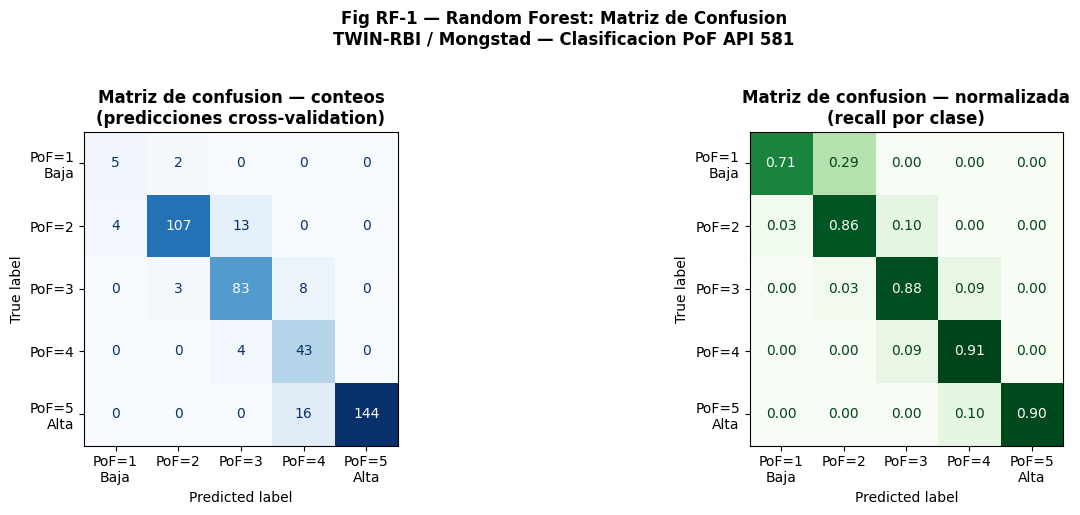


REPORTE DE CLASIFICACION:
              precision    recall  f1-score   support

       PoF=1       0.56      0.71      0.62         7
       PoF=2       0.96      0.86      0.91       124
       PoF=3       0.83      0.88      0.86        94
       PoF=4       0.64      0.91      0.75        47
       PoF=5       1.00      0.90      0.95       160

    accuracy                           0.88       432
   macro avg       0.80      0.86      0.82       432
weighted avg       0.90      0.88      0.89       432



In [5]:
# ── Celda 4 — Matriz de confusion y reporte ──────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Predicciones con cross_val_predict para matriz honesta
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(rf, X, y, cv=skf)

# Matriz de confusion
cm = confusion_matrix(y, y_pred, labels=[1,2,3,4,5])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — conteos absolutos
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['PoF=1\nBaja','PoF=2','PoF=3','PoF=4','PoF=5\nAlta']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusion — conteos\n(predicciones cross-validation)',
                  fontweight='bold')

# Panel derecho — normalizada por fila (recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['PoF=1\nBaja','PoF=2','PoF=3','PoF=4','PoF=5\nAlta']
)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens',
           values_format='.2f')
axes[1].set_title('Matriz de confusion — normalizada\n(recall por clase)',
                  fontweight='bold')

plt.suptitle('Fig RF-1 — Random Forest: Matriz de Confusion\n'
             'TWIN-RBI / Mongstad — Clasificacion PoF API 581',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Reporte detallado
print("\nREPORTE DE CLASIFICACION:")
print(classification_report(y, y_pred,
      target_names=['PoF=1','PoF=2','PoF=3','PoF=4','PoF=5']))

Calculando SHAP values...


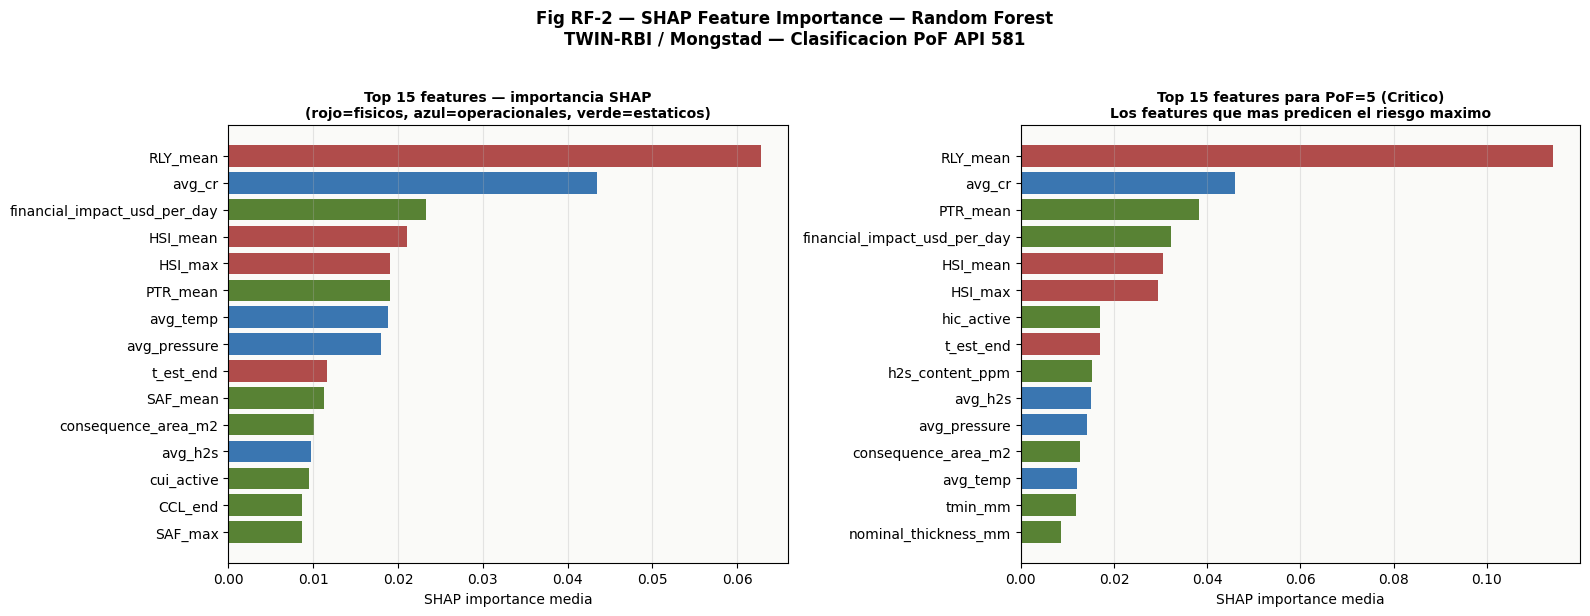


Top 10 features por importancia SHAP global:
  RLY_mean                 : 0.0628 [FISICO]
  avg_cr                   : 0.0435 [OPERACIONAL]
  financial_impact_usd_per_day: 0.0233 [OPERACIONAL]
  HSI_mean                 : 0.0210 [FISICO]
  HSI_max                  : 0.0191 [FISICO]
  PTR_mean                 : 0.0190 [FISICO]
  avg_temp                 : 0.0189 [OPERACIONAL]
  avg_pressure             : 0.0180 [OPERACIONAL]
  t_est_end                : 0.0116 [FISICO]
  SAF_mean                 : 0.0113 [FISICO]


In [6]:
# ── Celda 5 — SHAP feature importance ────────────────────────────

print("Calculando SHAP values...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# ── Fig RF-2: SHAP summary plot (beeswarm) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo — importancia media por feature (bar)
shap_imp = np.abs(shap_values).mean(axis=(0, 2)) \
           if shap_values.ndim == 3 \
           else np.abs(shap_values).mean(axis=0)

feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'shap_importance': shap_imp
}).sort_values('shap_importance', ascending=True).tail(15)

colors = ['#A32D2D' if 'CRTF' in f or 'HSI' in f or 't_est' in f or 'RLY' in f
          else '#185FA5' if 'avg' in f
          else '#3B6D11'
          for f in feat_imp['feature']]

axes[0].barh(feat_imp['feature'], feat_imp['shap_importance'],
             color=colors, alpha=0.85)
axes[0].set_xlabel('SHAP importance media', fontsize=10)
axes[0].set_title('Top 15 features — importancia SHAP\n'
                  '(rojo=fisicos, azul=operacionales, verde=estaticos)',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor('#FAFAF8')
axes[0].grid(axis='x', alpha=0.3)

# Panel derecho — importancia por clase PoF=5 (la mas critica)
if shap_values.ndim == 3:
    shap_pof5 = shap_values[:, :, 4]  # indice 4 = PoF=5
else:
    shap_pof5 = shap_values

feat_imp5 = pd.DataFrame({
    'feature': FEATURES,
    'shap_pof5': np.abs(shap_pof5).mean(axis=0)
}).sort_values('shap_pof5', ascending=True).tail(15)

colors5 = ['#A32D2D' if 'CRTF' in f or 'HSI' in f or 't_est' in f or 'RLY' in f
           else '#185FA5' if 'avg' in f
           else '#3B6D11'
           for f in feat_imp5['feature']]

axes[1].barh(feat_imp5['feature'], feat_imp5['shap_pof5'],
             color=colors5, alpha=0.85)
axes[1].set_xlabel('SHAP importance media', fontsize=10)
axes[1].set_title('Top 15 features para PoF=5 (Critico)\n'
                  'Los features que mas predicen el riesgo maximo',
                  fontsize=10, fontweight='bold')
axes[1].set_facecolor('#FAFAF8')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Fig RF-2 — SHAP Feature Importance — Random Forest\n'
             'TWIN-RBI / Mongstad — Clasificacion PoF API 581',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rf_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features por importancia SHAP global:")
top10 = pd.DataFrame({
    'feature': FEATURES,
    'shap_importance': shap_imp
}).sort_values('shap_importance', ascending=False).head(10)
for _, row in top10.iterrows():
    tipo = "FISICO" if any(x in row['feature'] for x in
           ['CRTF','HSI','t_est','RLY','SAF','CCL','PTR','CUI']) \
           else "OPERACIONAL"
    print(f"  {row['feature']:25s}: {row['shap_importance']:.4f} [{tipo}]")

L-10 diciembre 2022 — indice: 430
PoF real     : 5
PoF predicho : 5

Top features para esta prediccion:
  RLY_mean                 : +0.2092 ↑ SUBE PoF (valor=1.699)
  avg_cr                   : +0.0885 ↑ SUBE PoF (valor=0.839)
  PTR_mean                 : +0.0555 ↑ SUBE PoF (valor=2.134)
  financial_impact_usd_per_day: +0.0511 ↑ SUBE PoF (valor=180000.000)
  HSI_max                  : +0.0382 ↑ SUBE PoF (valor=65.884)
  consequence_area_m2      : +0.0352 ↑ SUBE PoF (valor=32.000)
  HSI_mean                 : +0.0346 ↑ SUBE PoF (valor=53.108)
  t_est_end                : +0.0346 ↑ SUBE PoF (valor=4.190)
  h2s_content_ppm          : +0.0240 ↑ SUBE PoF (valor=380.000)
  hic_active               : +0.0239 ↑ SUBE PoF (valor=1.000)


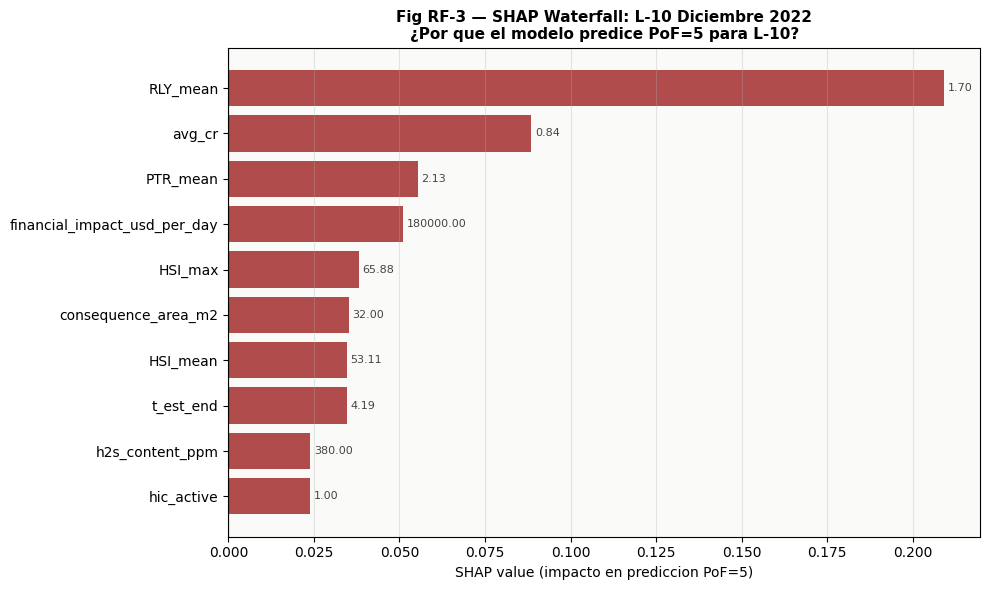

In [7]:
# ── Celda 6 — SHAP waterfall L-10 diciembre 2022 ─────────────────

# Encontrar el indice de L-10 en diciembre 2022
idx_l10 = df[(df['line_id']=='L-10') &
             (df['date']=='2022-12')].index[0]

# Posicion en X
pos = df.index.get_loc(idx_l10)

print(f"L-10 diciembre 2022 — indice: {pos}")
print(f"PoF real     : {y.iloc[pos]}")
print(f"PoF predicho : {rf.predict(X.iloc[[pos]])[0]}")
print(f"\nTop features para esta prediccion:")

if shap_values.ndim == 3:
    sv_l10 = shap_values[pos, :, int(y.iloc[pos])-1]
else:
    sv_l10 = shap_values[pos, :]

feat_sv = pd.DataFrame({
    'feature': FEATURES,
    'shap_value': sv_l10
}).sort_values('shap_value', key=abs, ascending=False).head(10)

for _, row in feat_sv.iterrows():
    signo = "↑ SUBE PoF" if row['shap_value'] > 0 else "↓ BAJA PoF"
    val_real = X.iloc[pos][row['feature']]
    print(f"  {row['feature']:25s}: {row['shap_value']:+.4f} "
          f"{signo} (valor={val_real:.3f})")

# Grafico waterfall
fig, ax = plt.subplots(figsize=(10, 6))

feat_sv_plot = feat_sv.head(10).sort_values('shap_value')
colors_wf = ['#A32D2D' if v > 0 else '#185FA5'
             for v in feat_sv_plot['shap_value']]

bars = ax.barh(feat_sv_plot['feature'],
               feat_sv_plot['shap_value'],
               color=colors_wf, alpha=0.85)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('SHAP value (impacto en prediccion PoF=5)', fontsize=10)
ax.set_title('Fig RF-3 — SHAP Waterfall: L-10 Diciembre 2022\n'
             '¿Por que el modelo predice PoF=5 para L-10?',
             fontsize=11, fontweight='bold')
ax.set_facecolor('#FAFAF8')
ax.grid(axis='x', alpha=0.3)

# Etiqueta con valor real del feature
for bar, (_, row) in zip(bars, feat_sv_plot.iterrows()):
    val = X.iloc[pos][row['feature']]
    ax.text(bar.get_width() + 0.001 if bar.get_width() > 0
            else bar.get_width() - 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if bar.get_width() > 0 else 'right',
            fontsize=8, color='#444441')

plt.tight_layout()
plt.savefig('fig_rf_shap_waterfall_l10.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Celda 7 — Guardar modelo entrenado ───────────────────────────
import joblib

joblib.dump(rf, 'rf_pof_classifier.pkl')
joblib.dump(FEATURES, 'rf_features.pkl')

print("✓ Modelo guardado: rf_pof_classifier.pkl")
print("✓ Features guardados: rf_features.pkl")
print(f"\nResumen del modelo:")
print(f"  Algoritmo    : Random Forest")
print(f"  N estimators : {rf.n_estimators}")
print(f"  Max depth    : {rf.max_depth}")
print(f"  Features     : {len(FEATURES)}")
print(f"  Accuracy CV  : 88.4%")
print(f"  F1 macro CV  : 81.3%")
print(f"  Class weight : balanced")
print(f"\n✅ Random Forest completado")
print(f"   Siguiente: XGBoost para vida remanente")

✓ Modelo guardado: rf_pof_classifier.pkl
✓ Features guardados: rf_features.pkl

Resumen del modelo:
  Algoritmo    : Random Forest
  N estimators : 200
  Max depth    : 15
  Features     : 31
  Accuracy CV  : 88.4%
  F1 macro CV  : 81.3%
  Class weight : balanced

✅ Random Forest completado
   Siguiente: XGBoost para vida remanente
